<>:113: SyntaxWarning: invalid escape sequence '\c'
<>:113: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nvleb\AppData\Local\Temp\ipykernel_20492\3506300570.py:113: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Temperature ($^\circ$C)', fontsize=12)
C:\Users\nvleb\AppData\Local\Temp\ipykernel_20492\3506300570.py:24: RuntimeWarning: Mean of empty slice
  dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["BottomTemp"])
C:\Users\nvleb\AppData\Local\Temp\ipykernel_20492\3506300570.py:24: RuntimeWarning: Mean of empty slice
  dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["BottomTemp"])
C:\Users\nvleb\AppData\Local\Temp\ipykernel_20492\3506300570.py:24: RuntimeWarning: Mean of empty slice
  dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorr

--- Surface Correlation < 0.2 on 2013-05-15 ---
Timestamp:        2013-05-15 19:40:00
Surface Salinity: 2.0495
--- Surface Correlation < 0.2 on 2013-05-17 ---
Timestamp:        2013-05-17 20:30:00
Surface Salinity: 2.3658
--- Bottom Correlation < 0.2 on 2013-05-18 ---
Timestamp:        2013-05-18 21:20:00
Bottom Salinity:  18.3450

--- Bottom Correlation < 0.2 on 2013-05-21 ---
Timestamp:        2013-05-21 12:50:00
Bottom Salinity:  22.5082



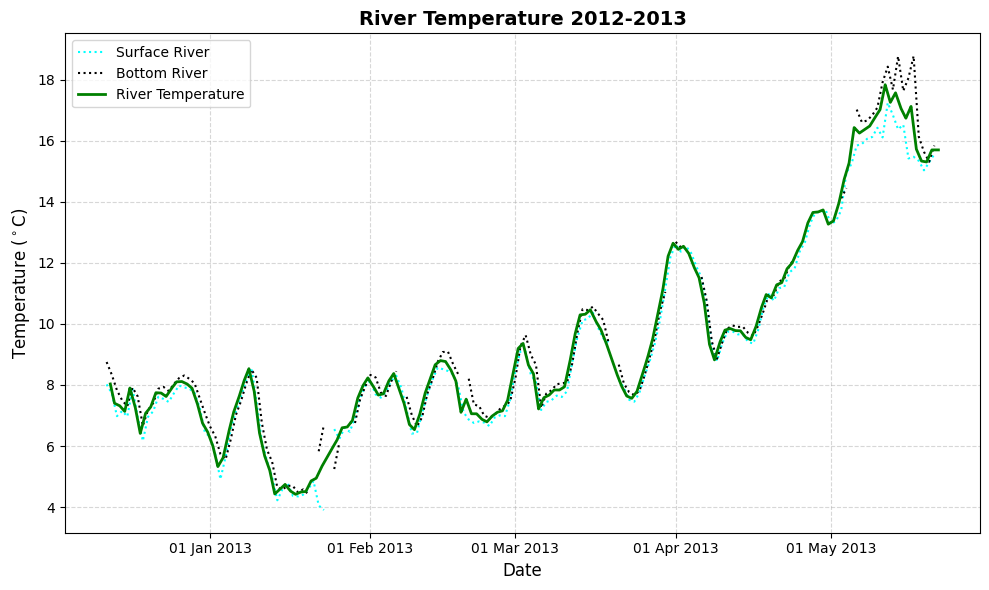

Total Occurrences (r < 0.2): 4


In [ ]:
import pandas as pd
import scipy.io as sio
from scipy import signal, stats
import numpy as np
import datetime
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

upRiverDF = pd.read_csv('upriver_2012_2013_processed.csv', parse_dates = ['DN'])
upRiverDF['dayDN'] = upRiverDF['DN'].dt.floor('D')
upRiverDF["surfaceRiver"] = np.nan
upRiverDF["bottomRiver"] = np.nan
coUNter = 0
dayDN = upRiverDF['dayDN'].drop_duplicates().to_list()

for dateMark in dayDN:
    if upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["SurfaceSalCorrected"] < 0.25)].shape[0] > 0:
        # since we have values lower than 0.25 salinity, we simply need to average those respective temperature values to find the river temperature 
        dailyRiverTemperatureSurface = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["SurfaceSalCorrected"] < 0.25)]["SurfaceTemp"])
        dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["BottomTemp"])
    else:
        # we need to plot all daily values in T vs S plots, then creating linear regression plots, to find the y-intercept for each, which gives us the average daily river temperature
        # r is the Pearson Coefficient, if linear regression is bad we need to get the appropriate temperature value for that day's low tide
        (slopeSurface, interceptSurface, rSurface, p, std_err) = stats.linregress(upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["SurfaceSalCorrected"].ffill().bfill().to_numpy(), upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["SurfaceTemp"].ffill().bfill().to_numpy(), alternative = "less")
        
        if abs(rSurface) < 0.2:
            # Get the exact index where the bottom pressure is at its minimum (low tide)
            low_tide_idx = upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["BottomPressure"].idxmin()
            low_tide_row = upRiverDF.loc[low_tide_idx]
            
            dailyRiverTemperatureSurface = low_tide_row['SurfaceTemp']
            
            # Print the specific timestamp and salinities
            print(f"--- Surface Correlation < 0.2 on {dateMark.strftime('%Y-%m-%d')} ---")
            print(f"Timestamp:        {low_tide_row['DN']}")
            print(f"Surface Salinity: {low_tide_row['SurfaceSalCorrected']:.4f}")
            
            coUNter += 1
        else:
            dailyRiverTemperatureSurface = interceptSurface
            
        (slopeBottom, interceptBottom, rBottom, p, std_err) = stats.linregress(upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["BottomSalCorrected"].ffill().bfill().to_numpy(), upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["BottomTemp"].ffill().bfill().to_numpy(), alternative = "less")
        
        if abs(rBottom) < 0.2:
            # Get the exact index where the bottom pressure is at its minimum (low tide)
            low_tide_idx = upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["BottomPressure"].idxmin()
            low_tide_row = upRiverDF.loc[low_tide_idx]
            
            dailyRiverTemperatureBottom = low_tide_row['BottomTemp']
            
            # Print the specific timestamp and salinities
            print(f"--- Bottom Correlation < 0.2 on {dateMark.strftime('%Y-%m-%d')} ---")
            print(f"Timestamp:        {low_tide_row['DN']}")
            print(f"Bottom Salinity:  {low_tide_row['BottomSalCorrected']:.4f}\n")
            
            coUNter += 1
        else:
            dailyRiverTemperatureBottom = interceptBottom
            
        #creating T vs S plots for each day where salinity doesn't get to 0.25
        salinityAxisSurface = [0]
        salinityAxisBottom = [0]
        linearRegressionPlot = [interceptSurface]
        linearRegressionPlotBottom = [interceptBottom]
        for surfaceSal in upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["SurfaceSalCorrected"]:
            linearRegressionPlot.append(surfaceSal * slopeSurface + interceptSurface)
            salinityAxisSurface.append(surfaceSal)
        for bottomSal in upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["BottomSalCorrected"]:
            linearRegressionPlotBottom.append(bottomSal * slopeBottom + interceptBottom)
            salinityAxisBottom.append(bottomSal)

    upRiverDF.loc[upRiverDF['dayDN'] == dateMark, "surfaceRiver"] = dailyRiverTemperatureSurface
    upRiverDF.loc[upRiverDF['dayDN'] == dateMark, "bottomRiver"] = dailyRiverTemperatureBottom


for index, row in upRiverDF.iterrows():
    dataPoint = 0
    countER = 0
    if not np.isnan(row["bottomRiver"]):
        dataPoint += row["bottomRiver"]
        countER += 1
    if not np.isnan(row["surfaceRiver"]):
        dataPoint += row["surfaceRiver"]
        countER += 1    
    if countER > 0:
        dataPoint = dataPoint/countER
        upRiverDF.loc[index, "EstimatedTemp"] = dataPoint


smoothedUpRiver = pd.read_csv('river_temperature_interpol12_13.csv', parse_dates = ['DN'])
upRiverDF.to_csv('river_temperature12_13.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Plot Surface and Bottom River Temp (Dotted lines via 'linestyle=":"')
ax.plot(upRiverDF['dayDN'], upRiverDF['surfaceRiver'], 
        color='cyan', linestyle=':', label='Surface River')

ax.plot(upRiverDF['dayDN'], upRiverDF['bottomRiver'], 
        color='black', linestyle=':', label='Bottom River')

# 2. Add the smoothed Estimated Temperature line (Solid green, width 2)
ax.plot(upRiverDF['DN'], smoothedUpRiver['EstimatedTemp'], 
        color='green', linewidth=2, label='River Temperature')

# 3. Add Title, Labels, and Legend
ax.set_title('River Temperature 2012-2013', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature ($^\circ$C)', fontsize=12)

# Display the legend to show the line labels
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))

# Tight layout and display/save
plt.tight_layout()
plt.show()

# Print total occurrences at the very end
print("====================================")
print(f"Total Occurrences (r < 0.2): {coUNter}")
print("====================================")